## The MIDI Composer (Algorithmic Music Harmonization)

Melody $\rightarrow$ Chord Progression

In [ ]:
import pickle
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
REST_IDX = 3
NUM_SPECIAL_TOKENS = 4  # PAD, SOS, EOS, REST

def load_and_prep_jsb_pkl(filepath):
    with open(filepath, 'rb') as f:
        jsb_data = pickle.load(f, encoding='latin1')

    unique_chords = set()
    for split in ['train', 'valid', 'test']:
        for chorale in jsb_data[split]:
            for time_step in chorale:
                chord_tuple = tuple(sorted(time_step))
                unique_chords.add(chord_tuple)

    # FIX: Start chord indices at NUM_SPECIAL_TOKENS (=4), not 3.
    # Index 3 is REST_IDX, so starting at 3 caused a collision.
    chord2idx = {chord: idx + NUM_SPECIAL_TOKENS for idx, chord in enumerate(sorted(unique_chords))}
    idx2chord = {idx: chord for chord, idx in chord2idx.items()}

    return jsb_data, chord2idx, idx2chord

filepath = 'jsb-chorales-16th.pkl'
jsb_data, chord2idx, idx2chord = load_and_prep_jsb_pkl(filepath)

melody_vocab_size = 128 + NUM_SPECIAL_TOKENS  # 132
# FIX: Account for all 4 special tokens (was len(chord2idx) + 3).
harmony_vocab_size = len(chord2idx) + NUM_SPECIAL_TOKENS

print(f"Melody Vocab Size: {melody_vocab_size}")
print(f"Harmony Vocab Size: {harmony_vocab_size}")

Melody Vocab Size: 132
Harmony Vocab Size: 5349


In [ ]:
class ChoraleDataset(Dataset):
    def __init__(self, data_split, chord2idx):
        self.data = data_split
        self.chord2idx = chord2idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        chorale = self.data[idx]

        melody_tokens = [SOS_IDX]
        harmony_tokens = [SOS_IDX]

        for time_step in chorale:
            if len(time_step) == 0:
                melody_tokens.append(REST_IDX)
            else:
                melody_pitch = max(time_step)
                # Pitches 0–127 shifted by NUM_SPECIAL_TOKENS so they don't
                # collide with PAD/SOS/EOS/REST. Max token = 127+4 = 131 < 132.
                melody_tokens.append(melody_pitch + NUM_SPECIAL_TOKENS)

            chord_tuple = tuple(sorted(time_step))
            harmony_tokens.append(self.chord2idx[chord_tuple])

        melody_tokens.append(EOS_IDX)
        harmony_tokens.append(EOS_IDX)

        return torch.tensor(melody_tokens, dtype=torch.long), torch.tensor(harmony_tokens, dtype=torch.long)

train_dataset = ChoraleDataset(jsb_data['train'], chord2idx)
test_dataset = ChoraleDataset(jsb_data['test'], chord2idx)
val_dataset = ChoraleDataset(jsb_data['valid'], chord2idx)

In [ ]:
def collate_batch(batch):
    melody_list, harmony_list = [], []
    for melody, harmony in batch:
        melody_list.append(melody)
        harmony_list.append(harmony)

    melody_padded = pad_sequence(melody_list, batch_first=True, padding_value=PAD_IDX)
    harmony_padded = pad_sequence(harmony_list, batch_first=True, padding_value=PAD_IDX)
    return melody_padded, harmony_padded

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_batch)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

for melodies, harmonies in train_loader:
    print("Train Melody batch shape:", melodies.shape)
    print("Train Harmony batch shape:", harmonies.shape)
    break

Train Melody batch shape: torch.Size([32, 454])
Train Harmony batch shape: torch.Size([32, 454])


In [ ]:
import torch
import torch.nn as nn
import math
import numpy as np
import pretty_midi

class MelodyHarmonizer(nn.Module):
    def __init__(
        self,
        melody_vocab_size,
        harmony_vocab_size,
        d_model=256,        
        nhead=8,
        num_layers=3,    
        dim_feedforward=1024,
        dropout=0.1,
        max_len=5000
    ):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        self.melody_embedding  = nn.Embedding(melody_vocab_size,  d_model, padding_idx=PAD_IDX)
        self.harmony_embedding = nn.Embedding(harmony_vocab_size, d_model, padding_idx=PAD_IDX)

        self.src_pos_embedding = nn.Embedding(max_len, d_model)
        self.tgt_pos_embedding = nn.Embedding(max_len, d_model)

        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.output_projection = nn.Linear(d_model, harmony_vocab_size)

    def forward(
        self,
        src,
        tgt,
        tgt_mask=None,
        src_key_padding_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None
    ):
        _, src_len = src.shape
        _, tgt_len = tgt.shape

        if src_len > self.max_len or tgt_len > self.max_len:
            raise ValueError(f"Sequence length exceeds max_len={self.max_len}")

        src_positions = torch.arange(src_len, device=src.device).unsqueeze(0)
        tgt_positions = torch.arange(tgt_len, device=tgt.device).unsqueeze(0)

        src_emb = self.melody_embedding(src)  * math.sqrt(self.d_model)
        tgt_emb = self.harmony_embedding(tgt) * math.sqrt(self.d_model)

        src_emb = src_emb + self.src_pos_embedding(src_positions)
        tgt_emb = tgt_emb + self.tgt_pos_embedding(tgt_positions)

        src_emb = self.dropout(src_emb)
        tgt_emb = self.dropout(tgt_emb)

        out = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.output_projection(out)

    def generate_square_subsequent_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MelodyHarmonizer(melody_vocab_size, harmony_vocab_size).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 10,868,453


In [ ]:


def train_model(model, dataloader, optimizer, criterion, epochs=20, device='cpu'):
    model.train()
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        n_batches = 0
        for melody, harmony in dataloader:
            melody  = melody.to(device=device, dtype=torch.long)
            harmony = harmony.to(device=device, dtype=torch.long)

            # Teacher forcing: decoder sees harmony[:, :-1], predicts harmony[:, 1:]
            tgt_input    = harmony[:, :-1]
            tgt_expected = harmony[:, 1:]

            tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)

            src_padding_mask = (melody == PAD_IDX)
            tgt_padding_mask = (tgt_input == PAD_IDX)

            optimizer.zero_grad()
            logits = model(
                melody,
                tgt_input,
                tgt_mask=tgt_mask,
                src_key_padding_mask=src_padding_mask,
                tgt_key_padding_mask=tgt_padding_mask,
                memory_key_padding_mask=src_padding_mask,
            )

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_expected.reshape(-1)
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)
        history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f}")
    return history

In [ ]:


def evaluate_model(model, dataloader, criterion, device='cpu'):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    with torch.no_grad():
        for melody, harmony in dataloader:
            melody  = melody.to(device=device, dtype=torch.long)
            harmony = harmony.to(device=device, dtype=torch.long)

            tgt_input    = harmony[:, :-1]
            tgt_expected = harmony[:, 1:]

            tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
            src_padding_mask = (melody == PAD_IDX)
            tgt_padding_mask = (tgt_input == PAD_IDX)

            logits = model(
                melody,
                tgt_input,
                tgt_mask=tgt_mask,
                src_key_padding_mask=src_padding_mask,
                tgt_key_padding_mask=tgt_padding_mask,
                memory_key_padding_mask=src_padding_mask,
            )
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_expected.reshape(-1)
            )
            total_loss += loss.item()
            n_batches += 1

    return total_loss / max(n_batches, 1)

In [ ]:
def harmonize_melody(model, melody_sequence, sos_token=SOS_IDX, eos_token=EOS_IDX,
                     max_len=512, device='cpu'):
    """Greedy autoregressive generation. melody_sequence: 1-D tensor or list."""
    model.eval()
    model.to(device)

    if not isinstance(melody_sequence, torch.Tensor):
        melody_sequence = torch.tensor(melody_sequence)
    melody = melody_sequence.unsqueeze(0).to(device)  # (1, src_len)

    tgt = torch.tensor([[sos_token]], device=device)

    for _ in range(max_len):
        tgt_mask = model.generate_square_subsequent_mask(tgt.size(1)).to(device)
        with torch.no_grad():
            output = model(melody, tgt, tgt_mask=tgt_mask)
            next_token = torch.argmax(output[:, -1, :], dim=-1).item()
            tgt = torch.cat([tgt, torch.tensor([[next_token]], device=device)], dim=1)
            if next_token == eos_token:
                break

    return tgt.squeeze(0).tolist()

In [ ]:

SPECIAL_TOKENS = {PAD_IDX, SOS_IDX, EOS_IDX, REST_IDX}

def tokens_to_midi(melody_tokens, harmony_tokens, idx2chord,
                   filename='bach_output.mid', tempo=100):
    """
    melody_tokens:  list of melody token IDs (with +4 offset; specials stripped here)
    harmony_tokens: list of chord token IDs (mapped via idx2chord)
    idx2chord:      dict mapping chord_token_id -> tuple of MIDI pitches
    """
    midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    melody_inst  = pretty_midi.Instrument(program=0, name='Soprano Melody')
    harmony_inst = pretty_midi.Instrument(program=0, name='Chord Accompaniment')

    seconds_per_beat = 60.0 / tempo
    step_duration = seconds_per_beat / 4.0  # 16th note

    # Melody — skip specials, undo the +4 offset
    for i, tok in enumerate(melody_tokens):
        if tok in SPECIAL_TOKENS:
            continue
        pitch = tok - NUM_SPECIAL_TOKENS
        if 0 <= pitch <= 127:
            start = i * step_duration
            end   = start + step_duration
            melody_inst.notes.append(
                pretty_midi.Note(velocity=100, pitch=pitch, start=start, end=end)
            )

    # Harmony — look up chord tuple, skip specials and unknowns
    for i, tok in enumerate(harmony_tokens):
        if tok in SPECIAL_TOKENS or tok not in idx2chord:
            continue
        chord_pitches = idx2chord[tok]
        if not chord_pitches:
            continue
        start = i * step_duration
        end   = start + step_duration
        for pitch in chord_pitches:
            if 0 <= pitch <= 127:
                harmony_inst.notes.append(
                    pretty_midi.Note(velocity=80, pitch=pitch, start=start, end=end)
                )

    midi.instruments.append(melody_inst)
    midi.instruments.append(harmony_inst)
    midi.write(filename)
    print(f"Saved generated audio to {filename}")

In [ ]:


num_epochs = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_history = train_model(
        model, train_loader, optimizer, criterion,
        epochs=1, device=device
    )
    val_loss = evaluate_model(model, val_loader, criterion, device=device)
    print(f"  -> Validation Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  -> Saved new best model (val_loss={val_loss:.4f})")

print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")

c:\MIX\ASU\SEM_4\LLM_Basics\phase2\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 1/1 | Train Loss: 8.4853


c:\MIX\ASU\SEM_4\LLM_Basics\phase2\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


  -> Validation Loss: 8.2954
  -> Saved new best model (val_loss=8.2954)
Epoch 1/1 | Train Loss: 8.1518
  -> Validation Loss: 8.0489
  -> Saved new best model (val_loss=8.0489)
Epoch 1/1 | Train Loss: 7.8914
  -> Validation Loss: 7.8153
  -> Saved new best model (val_loss=7.8153)
Epoch 1/1 | Train Loss: 7.6470
  -> Validation Loss: 7.5906
  -> Saved new best model (val_loss=7.5906)
Epoch 1/1 | Train Loss: 7.4159
  -> Validation Loss: 7.3753
  -> Saved new best model (val_loss=7.3753)
Epoch 1/1 | Train Loss: 7.2535
  -> Validation Loss: 7.1777
  -> Saved new best model (val_loss=7.1777)
Epoch 1/1 | Train Loss: 6.9982
  -> Validation Loss: 6.9854
  -> Saved new best model (val_loss=6.9854)
Epoch 1/1 | Train Loss: 6.8244
  -> Validation Loss: 6.8094
  -> Saved new best model (val_loss=6.8094)
Epoch 1/1 | Train Loss: 6.6776
  -> Validation Loss: 6.6509
  -> Saved new best model (val_loss=6.6509)
Epoch 1/1 | Train Loss: 6.4792
  -> Validation Loss: 6.5090
  -> Saved new best model (val_loss

In [ ]:
# Example: harmonize the first melody from the validation set and save MIDI.

sample_melody, sample_harmony_gt = val_dataset[0]
predicted_harmony = harmonize_melody(
    model, sample_melody,
    sos_token=SOS_IDX, eos_token=EOS_IDX,
    max_len=sample_melody.size(0) + 16,
    device=device
)

print(f"Melody length: {sample_melody.size(0)}")
print(f"Predicted harmony length: {len(predicted_harmony)}")

tokens_to_midi(
    sample_melody.tolist(),
    predicted_harmony,
    idx2chord,
    filename='bach_output.mid',
    tempo=50
)

Melody length: 198
Predicted harmony length: 215
Saved generated audio to bach_output.mid


---
## The MIDI Composer (Algorithmic Music Harmonization) _ V2
- Soprano → Alto, 
- then Soprano + ground-truth Alto → Tenor, 
- then Soprano + ground-truth Alto + ground-truth Tenor → Bass

In [ ]:
import math
import pickle
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import pretty_midi

In [ ]:
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
REST_IDX = 3
GEN_ALTO_IDX = 4
GEN_TENOR_IDX = 5
GEN_BASS_IDX = 6
SEP_IDX = 7
NUM_SPECIAL_TOKENS = 8

VOCAB_SIZE = 128 + NUM_SPECIAL_TOKENS  # 136

TASK_TOKENS = {
    'alto':  GEN_ALTO_IDX,
    'tenor': GEN_TENOR_IDX,
    'bass':  GEN_BASS_IDX,
}

def pitch_to_tok(p):
    """Encode a MIDI pitch (0..127) or None (rest) into a token id."""
    if p is None:
        return REST_IDX
    return p + NUM_SPECIAL_TOKENS

def tok_to_pitch(t):
    """Inverse of pitch_to_tok. Returns None for non-pitch tokens."""
    if t < NUM_SPECIAL_TOKENS:
        return None
    return t - NUM_SPECIAL_TOKENS

print(f"Shared vocab size: {VOCAB_SIZE}")

Shared vocab size: 136


In [ ]:
def load_jsb_satb(filepath):
    """Return a dict of split -> list of dicts {S, A, T, B}, each a list of token IDs."""
    with open(filepath, 'rb') as f:
        jsb_data = pickle.load(f, encoding='latin1')

    out = {}
    for split in ['train', 'valid', 'test']:
        chorales = []
        for chorale in jsb_data[split]:
            S, A, T, B = [], [], [], []
            for step in chorale:
                # step is typically a tuple of 4 pitches sorted high->low (S,A,T,B)
                # but can be shorter if voices drop out. Fill missing with REST.
                pitches = sorted(step, reverse=True) if len(step) > 0 else []
                voices = [pitches[i] if i < len(pitches) else None for i in range(4)]
                S.append(pitch_to_tok(voices[0]))
                A.append(pitch_to_tok(voices[1]))
                T.append(pitch_to_tok(voices[2]))
                B.append(pitch_to_tok(voices[3]))
            chorales.append({'S': S, 'A': A, 'T': T, 'B': B})
        out[split] = chorales
    return out

filepath = 'jsb-chorales-16th.pkl'
satb_data = load_jsb_satb(filepath)

print(f"Train chorales: {len(satb_data['train'])}")
print(f"Valid chorales: {len(satb_data['valid'])}")
print(f"Test  chorales: {len(satb_data['test'])}")
print(f"Example chorale length (timesteps): {len(satb_data['train'][0]['S'])}")

Train chorales: 229
Valid chorales: 76
Test  chorales: 77
Example chorale length (timesteps): 192


In [ ]:
class SATBMultitaskDataset(Dataset):
    """
    Each item = one (task, chorale) pair. We materialize the cross product so the
    DataLoader shuffles tasks together; the model sees a roughly uniform mix.
    """
    TASKS = ('alto', 'tenor', 'bass')

    def __init__(self, split_data):
        self.examples = []
        for chorale in split_data:
            for task in self.TASKS:
                self.examples.append((task, chorale))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        task, chorale = self.examples[idx]
        S, A, T, B = chorale['S'], chorale['A'], chorale['T'], chorale['B']
        task_tok = TASK_TOKENS[task]

        if task == 'alto':
            src = [task_tok] + S
            tgt = [SOS_IDX] + A + [EOS_IDX]
        elif task == 'tenor':
            src = [task_tok] + S + [SEP_IDX] + A
            tgt = [SOS_IDX] + T + [EOS_IDX]
        else:  # bass
            src = [task_tok] + S + [SEP_IDX] + A + [SEP_IDX] + T
            tgt = [SOS_IDX] + B + [EOS_IDX]

        return (
            torch.tensor(src, dtype=torch.long),
            torch.tensor(tgt, dtype=torch.long),
        )

def collate_batch(batch):
    src_list, tgt_list = zip(*batch)
    src_padded = pad_sequence(src_list, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_list, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded

train_dataset = SATBMultitaskDataset(satb_data['train'])
val_dataset   = SATBMultitaskDataset(satb_data['valid'])
test_dataset  = SATBMultitaskDataset(satb_data['test'])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_batch)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

for src, tgt in train_loader:
    print("Train src batch shape:", src.shape)
    print("Train tgt batch shape:", tgt.shape)
    break

Train src batch shape: torch.Size([32, 1359])
Train tgt batch shape: torch.Size([32, 454])


In [ ]:
class SATBHarmonizer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=256,
        nhead=8,
        num_layers=3,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=5000,
    ):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        # Shared embedding for src and tgt because they share a vocab.
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.src_pos_embedding = nn.Embedding(max_len, d_model)
        self.tgt_pos_embedding = nn.Embedding(max_len, d_model)

        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        self.output_projection = nn.Linear(d_model, vocab_size)

    def forward(
        self,
        src,
        tgt,
        tgt_mask=None,
        src_key_padding_mask=None,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None,
    ):
        _, src_len = src.shape
        _, tgt_len = tgt.shape

        if src_len > self.max_len or tgt_len > self.max_len:
            raise ValueError(f"Sequence length exceeds max_len={self.max_len}")

        src_positions = torch.arange(src_len, device=src.device).unsqueeze(0)
        tgt_positions = torch.arange(tgt_len, device=tgt.device).unsqueeze(0)

        src_emb = self.token_embedding(src) * math.sqrt(self.d_model)
        tgt_emb = self.token_embedding(tgt) * math.sqrt(self.d_model)

        src_emb = src_emb + self.src_pos_embedding(src_positions)
        tgt_emb = tgt_emb + self.tgt_pos_embedding(tgt_positions)

        src_emb = self.dropout(src_emb)
        tgt_emb = self.dropout(tgt_emb)

        out = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        return self.output_projection(out)

    def generate_square_subsequent_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SATBHarmonizer(VOCAB_SIZE).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"Device: {device}")

Trainable parameters: 8,160,392
Device: cuda


### Step 1: `torch.ones(sz, sz)`
First, the inner part of the first line creates a square matrix of size `sz` by `sz` filled entirely with 1s. 

If `sz = 4`, it looks like this:

$$\begin{bmatrix}1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 \end{bmatrix}$$

### Step 2: `torch.triu(..., diagonal=1)`
`torch.triu` stands for **tri**angular **u**pper. It isolates the upper right triangle of a matrix and turns everything below it into 0s. 

By setting `diagonal=1`, we tell PyTorch to exclude the main diagonal (which becomes 0) and only keep the 1s that are *strictly above* the main diagonal.

$$\begin{bmatrix}0 & 1 & 1 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \end{bmatrix}$$

At this point:
* `0` represents positions the model is **allowed** to look at.
* `1` represents future positions the model needs to be **blocked** from seeing.

### Step 3: `mask.masked_fill(mask == 1, float('-inf'))`
Finally, this line searches the matrix for any value that equals `1` and replaces it with negative infinity (`-inf`). The `0`s are left alone.

$$\begin{bmatrix}0 & -\infty & -\infty & -\infty \\ 0 & 0 & -\infty & -\infty \\ 0 & 0 & 0 & -\infty \\ 0 & 0 & 0 & 0 \end{bmatrix}$$

---

### Why negative infinity ($-\infty$) and zero ($0$)?

To understand why the matrix looks like this, we have to look at how the Transformer calculates attention. 

Inside the self-attention mechanism, the model computes raw "attention scores" between every token in the sequence. Before these scores are turned into probabilities, this mask is **added** directly to those scores.

Let's say the model calculates the raw attention scores for Token 2. It wants to know how much to focus on Tokens 1, 2, 3, and 4. 

1.  **For past/present tokens (Tokens 1 and 2):** The mask adds `0` to the raw score. Adding zero does nothing, so the score remains intact.
2.  **For future tokens (Tokens 3 and 4):** The mask adds $-\infty$ to the raw score. Anything plus negative infinity equals negative infinity.

Next, the attention mechanism passes these scores through a **Softmax** function to turn them into percentages that add up to 100%. 

Because $e^{-\infty} = 0$, **Softmax converts all the $-\infty$ values into hard $0$s.** This guarantees that Token 2 puts exactly $0\%$ of its attention on Token 3 and Token 4, forcing the model to predict the next note based strictly on the music that has already been played.

In [ ]:
def train_model(model, dataloader, optimizer, criterion, epochs=1, device='cpu'):
    model.train()
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        n_batches = 0
        for src, tgt in dataloader:
            src = src.to(device=device, dtype=torch.long)
            tgt = tgt.to(device=device, dtype=torch.long)

            tgt_input    = tgt[:, :-1]
            tgt_expected = tgt[:, 1:]

            tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
            src_padding_mask = (src == PAD_IDX)
            tgt_padding_mask = (tgt_input == PAD_IDX)

            optimizer.zero_grad()
            logits = model(
                src,
                tgt_input,
                tgt_mask=tgt_mask,
                src_key_padding_mask=src_padding_mask,
                tgt_key_padding_mask=tgt_padding_mask,
                memory_key_padding_mask=src_padding_mask,
            )
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_expected.reshape(-1),
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)
        history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f}")
    return history

def evaluate_model(model, dataloader, criterion, device='cpu'):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    with torch.no_grad():
        for src, tgt in dataloader:
            src = src.to(device=device, dtype=torch.long)
            tgt = tgt.to(device=device, dtype=torch.long)

            tgt_input    = tgt[:, :-1]
            tgt_expected = tgt[:, 1:]

            tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
            src_padding_mask = (src == PAD_IDX)
            tgt_padding_mask = (tgt_input == PAD_IDX)

            logits = model(
                src,
                tgt_input,
                tgt_mask=tgt_mask,
                src_key_padding_mask=src_padding_mask,
                tgt_key_padding_mask=tgt_padding_mask,
                memory_key_padding_mask=src_padding_mask,
            )
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_expected.reshape(-1),
            )
            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(n_batches, 1)

In [7]:
num_epochs = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_model(model, train_loader, optimizer, criterion, epochs=1, device=device)
    val_loss = evaluate_model(model, val_loader, criterion, device=device)
    print(f"  -> Validation Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_satb_model.pt')
        print(f"  -> Saved new best model (val_loss={val_loss:.4f})")

print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")

c:\MIX\ASU\SEM_4\LLM_Basics\phase2\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 1/1 | Train Loss: 3.2103


c:\MIX\ASU\SEM_4\LLM_Basics\phase2\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


  -> Validation Loss: 1.9007
  -> Saved new best model (val_loss=1.9007)
Epoch 1/1 | Train Loss: 1.6520
  -> Validation Loss: 1.2907
  -> Saved new best model (val_loss=1.2907)
Epoch 1/1 | Train Loss: 1.2621
  -> Validation Loss: 1.1381
  -> Saved new best model (val_loss=1.1381)
Epoch 1/1 | Train Loss: 1.1420
  -> Validation Loss: 1.0771
  -> Saved new best model (val_loss=1.0771)
Epoch 1/1 | Train Loss: 1.0893
  -> Validation Loss: 1.0405
  -> Saved new best model (val_loss=1.0405)
Epoch 1/1 | Train Loss: 1.0553
  -> Validation Loss: 1.0172
  -> Saved new best model (val_loss=1.0172)
Epoch 1/1 | Train Loss: 1.0312
  -> Validation Loss: 1.0001
  -> Saved new best model (val_loss=1.0001)
Epoch 1/1 | Train Loss: 1.0165
  -> Validation Loss: 0.9891
  -> Saved new best model (val_loss=0.9891)
Epoch 1/1 | Train Loss: 1.0019
  -> Validation Loss: 0.9791
  -> Saved new best model (val_loss=0.9791)
Epoch 1/1 | Train Loss: 0.9928
  -> Validation Loss: 0.9757
  -> Saved new best model (val_loss

Epoch 1/1 | Train Loss: 3.2413


c:\MIX\ASU\SEM_4\LLM_Basics\phase2\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


  -> Validation Loss: 1.9050
  -> Saved new best model (val_loss=1.9050)
Epoch 1/1 | Train Loss: 1.6641
  -> Validation Loss: 1.2918
  -> Saved new best model (val_loss=1.2918)
Epoch 1/1 | Train Loss: 1.2513
  -> Validation Loss: 1.1387
  -> Saved new best model (val_loss=1.1387)
Epoch 1/1 | Train Loss: 1.1411
  -> Validation Loss: 1.0769
  -> Saved new best model (val_loss=1.0769)
Epoch 1/1 | Train Loss: 1.0865
  -> Validation Loss: 1.0386
  -> Saved new best model (val_loss=1.0386)
Epoch 1/1 | Train Loss: 1.0543
  -> Validation Loss: 1.0168
  -> Saved new best model (val_loss=1.0168)
Epoch 1/1 | Train Loss: 1.0336
  -> Validation Loss: 1.0024
  -> Saved new best model (val_loss=1.0024)
Epoch 1/1 | Train Loss: 1.0176
  -> Validation Loss: 0.9900
  -> Saved new best model (val_loss=0.9900)
Epoch 1/1 | Train Loss: 1.0043
  -> Validation Loss: 0.9802
  -> Saved new best model (val_loss=0.9802)
Epoch 1/1 | Train Loss: 0.9946
  -> Validation Loss: 0.9747
  -> Saved new best model (val_loss

In [8]:
def evaluate_per_task(model, split_data, criterion, device='cpu', batch_size=32):
    """Evaluate val loss separately for each task by filtering examples."""
    out = {}
    for task in SATBMultitaskDataset.TASKS:
        # Build a single-task dataset on the fly.
        ds = SATBMultitaskDataset(split_data)
        ds.examples = [ex for ex in ds.examples if ex[0] == task]
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
        out[task] = evaluate_model(model, loader, criterion, device=device)
    return out

per_task = evaluate_per_task(model, satb_data['valid'], criterion, device=device)
for task, loss in per_task.items():
    print(f"  {task:5s} val loss: {loss:.4f}")

  alto  val loss: 0.8498
  tenor val loss: 0.8839
  bass  val loss: 1.0871


In [9]:
@torch.no_grad()
def generate_voice(model, src_tokens, target_len, device='cpu'):
    """Greedy autoregressive decode of one voice.
    src_tokens: 1-D list/tensor of encoder input tokens (already includes task token).
    target_len: number of pitch tokens to generate (typically len(soprano)).
    Returns: list of pitch tokens (length target_len), without SOS/EOS.
    """
    model.eval()
    if not isinstance(src_tokens, torch.Tensor):
        src_tokens = torch.tensor(src_tokens, dtype=torch.long)
    src = src_tokens.unsqueeze(0).to(device)

    tgt = torch.tensor([[SOS_IDX]], device=device, dtype=torch.long)
    generated = []

    # We always emit exactly target_len pitch tokens. Aligned with the soprano
    # length keeps the four voices time-aligned. We ignore EOS in case the model
    # tries to stop early; this yields a fixed-length voice for clean assembly.
    for _ in range(target_len):
        tgt_mask = model.generate_square_subsequent_mask(tgt.size(1)).to(device)
        logits = model(src, tgt, tgt_mask=tgt_mask)
        next_logits = logits[:, -1, :].clone()

        # Discourage emitting structural tokens at pitch positions.
        for forbidden in (PAD_IDX, SOS_IDX, EOS_IDX,
                          GEN_ALTO_IDX, GEN_TENOR_IDX, GEN_BASS_IDX, SEP_IDX):
            next_logits[:, forbidden] = float('-inf')

        next_tok = torch.argmax(next_logits, dim=-1).item()
        generated.append(next_tok)
        tgt = torch.cat([tgt, torch.tensor([[next_tok]], device=device)], dim=1)

    return generated

@torch.no_grad()
def harmonize_satb(model, soprano_tokens, device='cpu'):
    """Take a Soprano voice (list of pitch tokens, no SOS/EOS) and return predicted A, T, B."""
    n = len(soprano_tokens)

    # 1) Alto from Soprano
    src_alto = [GEN_ALTO_IDX] + list(soprano_tokens)
    A_pred = generate_voice(model, src_alto, target_len=n, device=device)

    # 2) Tenor from Soprano + predicted Alto
    src_tenor = [GEN_TENOR_IDX] + list(soprano_tokens) + [SEP_IDX] + A_pred
    T_pred = generate_voice(model, src_tenor, target_len=n, device=device)

    # 3) Bass from Soprano + predicted Alto + predicted Tenor
    src_bass = ([GEN_BASS_IDX] + list(soprano_tokens) +
                [SEP_IDX] + A_pred + [SEP_IDX] + T_pred)
    B_pred = generate_voice(model, src_bass, target_len=n, device=device)

    return A_pred, T_pred, B_pred

In [10]:
SPECIAL_TOKENS = {PAD_IDX, SOS_IDX, EOS_IDX, REST_IDX,
                  GEN_ALTO_IDX, GEN_TENOR_IDX, GEN_BASS_IDX, SEP_IDX}

def satb_to_midi(S, A, T, B, filename='bach_satb.mid', tempo=60):
    """S, A, T, B are lists of pitch token IDs of equal length."""
    midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instruments = {
        'Soprano': pretty_midi.Instrument(program=52, name='Soprano'),
        'Alto':    pretty_midi.Instrument(program=52, name='Alto'),
        'Tenor':   pretty_midi.Instrument(program=52, name='Tenor'),
        'Bass':    pretty_midi.Instrument(program=52, name='Bass'),
    }

    seconds_per_beat = 60.0 / tempo
    step_duration = seconds_per_beat / 4.0  # 16th note

    voices = [('Soprano', S), ('Alto', A), ('Tenor', T), ('Bass', B)]
    for name, tokens in voices:
        inst = instruments[name]
        for i, tok in enumerate(tokens):
            if tok in SPECIAL_TOKENS:
                continue
            pitch = tok_to_pitch(tok)
            if pitch is None or not (0 <= pitch <= 127):
                continue
            start = i * step_duration
            end   = start + step_duration
            inst.notes.append(
                pretty_midi.Note(velocity=90, pitch=pitch, start=start, end=end)
            )
        midi.instruments.append(inst)

    midi.write(filename)
    print(f"Saved SATB score to {filename}")

In [11]:
# Demo: take the soprano of the first validation chorale, predict A/T/B, write MIDI.
sample = satb_data['valid'][0]
soprano = sample['S']

A_pred, T_pred, B_pred = harmonize_satb(model, soprano, device=device)

print(f"Soprano length: {len(soprano)}")
print(f"Predicted Alto/Tenor/Bass lengths: {len(A_pred)}, {len(T_pred)}, {len(B_pred)}")

satb_to_midi(soprano, A_pred, T_pred, B_pred, filename='bach_satb_predicted.mid', tempo=50)

# Also save the ground-truth chorale for comparison.
satb_to_midi(sample['S'], sample['A'], sample['T'], sample['B'],
             filename='bach_satb_groundtruth.mid', tempo=50)

Soprano length: 196
Predicted Alto/Tenor/Bass lengths: 196, 196, 196
Saved SATB score to bach_satb_predicted.mid
Saved SATB score to bach_satb_groundtruth.mid


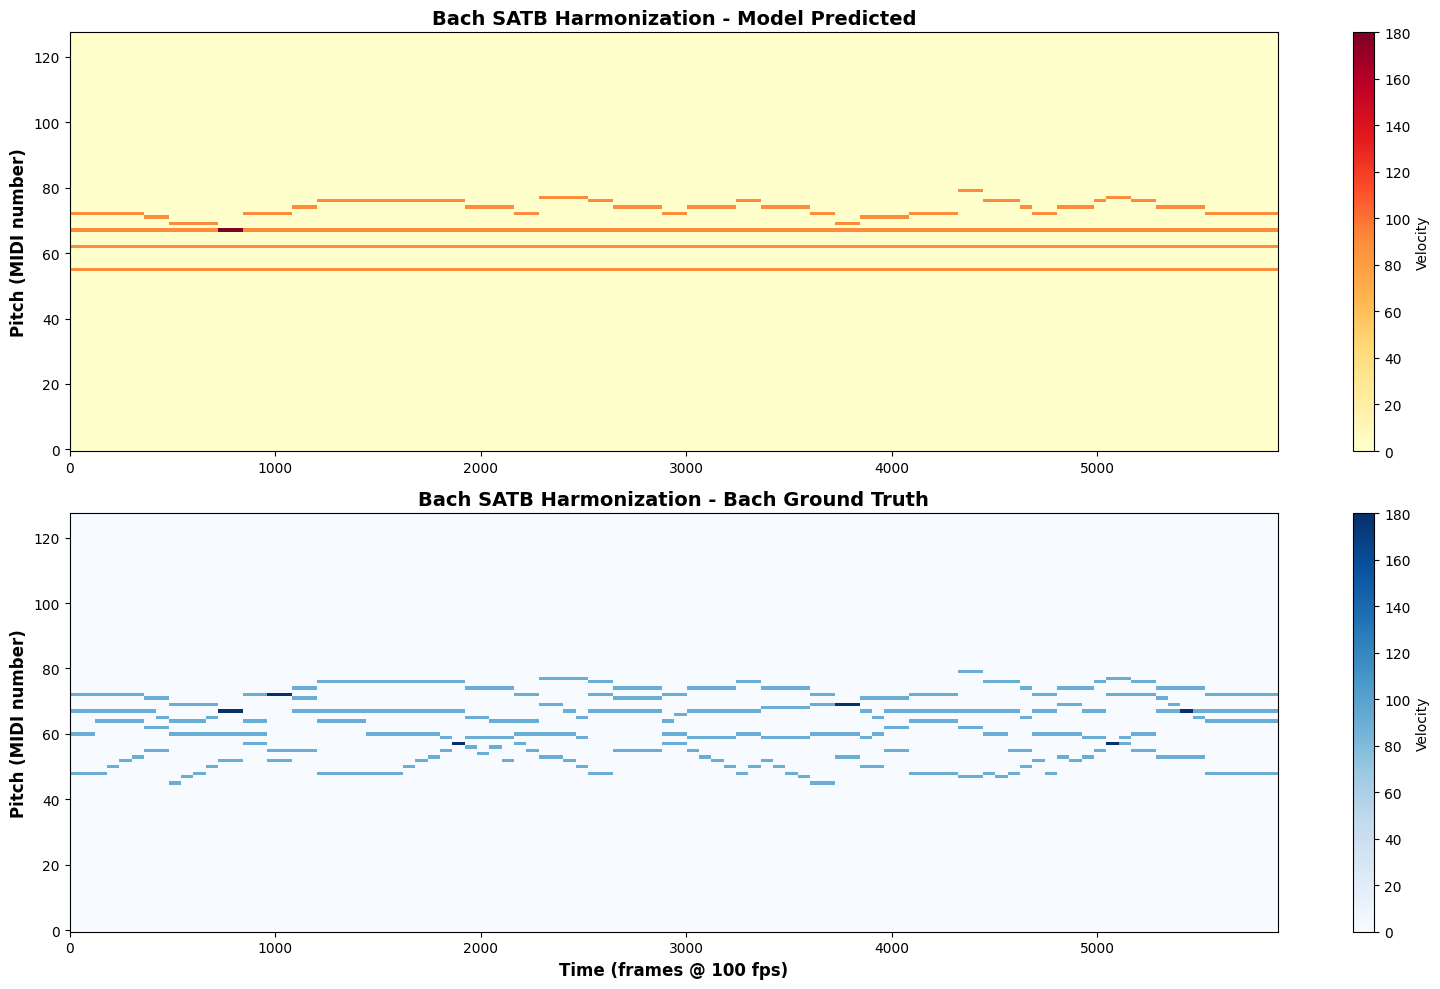

Piano roll comparison saved as 'satb_comparison_piano_roll.png'
Predicted MIDI duration: 58.80s
Ground truth MIDI duration: 58.80s


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_midi_comparison(predicted_file, groundtruth_file, title="SATB Harmonization Comparison"):
    """
    Visualize piano rolls of predicted vs. ground-truth MIDI files side-by-side.
    """
    # Load MIDI files
    midi_pred = pretty_midi.PrettyMIDI(predicted_file)
    midi_truth = pretty_midi.PrettyMIDI(groundtruth_file)
    
    # Get the end time (use max of both)
    end_time = max(midi_pred.get_end_time(), midi_truth.get_end_time())
    
    # Create piano rolls (resolution in frames per second)
    fps = 100  # frames per second for smooth resolution
    roll_pred = midi_pred.get_piano_roll(fs=fps)
    roll_truth = midi_truth.get_piano_roll(fs=fps)
    
    # Pad to same length
    max_len = max(roll_pred.shape[1], roll_truth.shape[1])
    if roll_pred.shape[1] < max_len:
        roll_pred = np.pad(roll_pred, ((0, 0), (0, max_len - roll_pred.shape[1])), mode='constant')
    if roll_truth.shape[1] < max_len:
        roll_truth = np.pad(roll_truth, ((0, 0), (0, max_len - roll_truth.shape[1])), mode='constant')
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    
    # Plot predicted
    img1 = ax1.imshow(roll_pred, aspect='auto', origin='lower', cmap='YlOrRd', interpolation='nearest')
    ax1.set_ylabel('Pitch (MIDI number)', fontsize=12, fontweight='bold')
    ax1.set_title(f'{title} - Model Predicted', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, max_len)
    plt.colorbar(img1, ax=ax1, label='Velocity')
    
    # Plot ground truth
    img2 = ax2.imshow(roll_truth, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
    ax2.set_xlabel('Time (frames @ 100 fps)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Pitch (MIDI number)', fontsize=12, fontweight='bold')
    ax2.set_title(f'{title} - Bach Ground Truth', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, max_len)
    plt.colorbar(img2, ax=ax2, label='Velocity')
    
    plt.tight_layout()
    plt.savefig('satb_comparison_piano_roll.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Piano roll comparison saved as 'satb_comparison_piano_roll.png'")
    print(f"Predicted MIDI duration: {midi_pred.get_end_time():.2f}s")
    print(f"Ground truth MIDI duration: {midi_truth.get_end_time():.2f}s")

# Generate the visualization
visualize_midi_comparison('bach_satb_predicted.mid', 'bach_satb_groundtruth.mid', 
                          title="Bach SATB Harmonization")